### **IMPORTING LIBRARIES**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

**### LOADING DATASET**

In [28]:
df = pd.read_csv("heart.csv")

# Fix age column name
df.rename(columns={'ï»¿age':'age'}, inplace=True)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**### DATASET INFORMATION**

In [29]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**### MISSING VALUES**

In [30]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

**### EXPLORATORY DATA ANALYSIS**

**# TARGET DISTRIBUTION**

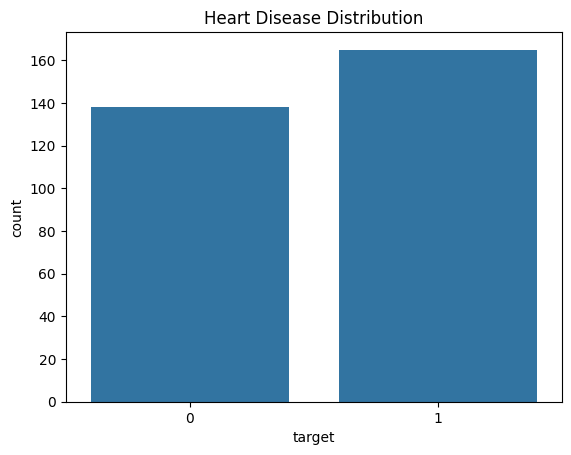

target
1    165
0    138
Name: count, dtype: int64


In [31]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

print(df['target'].value_counts())

**# AGE DISTRIBUTION**

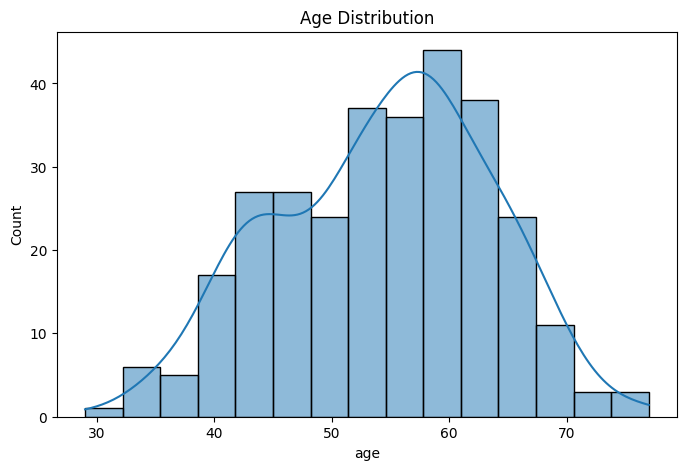

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=15, kde=True)
plt.title("Age Distribution")
plt.show()

**# CORRELATION HEATMAP**

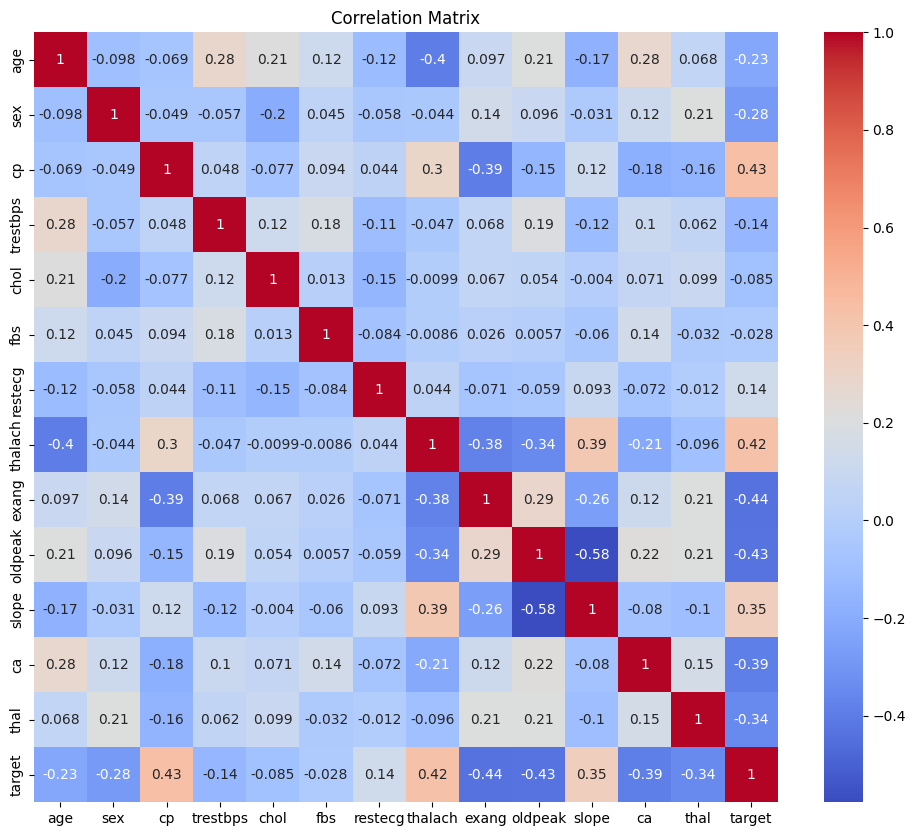

In [33]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**### FEATURE SELECTION**

In [34]:
X = df.drop('target', axis=1)
y = df['target']

**### TRAIN TEST SPLIT**

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(242, 13)
(61, 13)


**### FEATURE SCALING**

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**### ML MODEL TRAINING**

**# LOGISTIC REGRESSION**

In [37]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



**# DECISION TREE**

In [38]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7049180327868853
              precision    recall  f1-score   support

           0       0.71      0.61      0.65        28
           1       0.70      0.79      0.74        33

    accuracy                           0.70        61
   macro avg       0.71      0.70      0.70        61
weighted avg       0.71      0.70      0.70        61



**# RANDOM FOREST**

In [39]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print(classification_report(y_test, y_pred))

Accuracy: 0.8360655737704918

              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



**# AI MODEL - MLPClassifier**

In [40]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, y_pred_mlp))

print(classification_report(y_test, y_pred_mlp))

Accuracy: 0.7213114754098361
              precision    recall  f1-score   support

           0       0.74      0.61      0.67        28
           1       0.71      0.82      0.76        33

    accuracy                           0.72        61
   macro avg       0.72      0.71      0.71        61
weighted avg       0.72      0.72      0.72        61



**### HYPERPARAMETER TUNING (RANDOM FOREST)**

In [41]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross Validation Accuracy:
0.8349489795918368


**### EVALUATE BEST RANDOM FOREST**

In [42]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Final Accuracy:",
      accuracy_score(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

Final Accuracy: 0.819672131147541
              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



**### CONFUSION MATRICES**

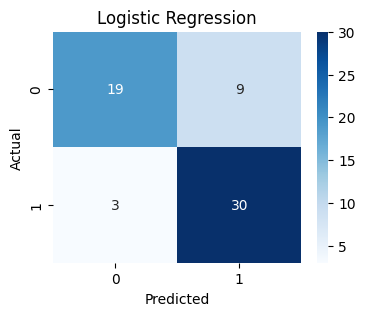

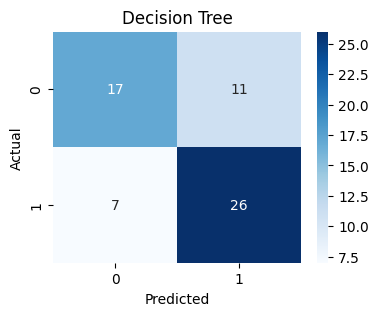

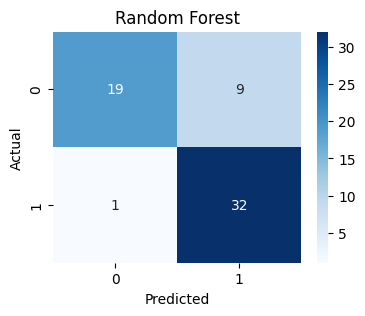

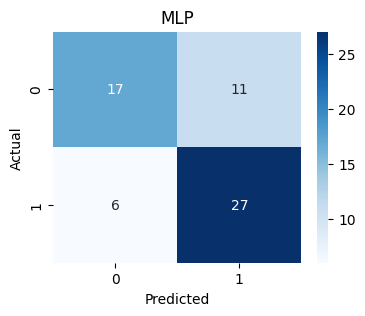

In [43]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_mlp = mlp.predict(X_test_scaled)

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "MLP": y_pred_mlp
}

for name, pred in models.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, pred),
                annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**### ROC CURVES**

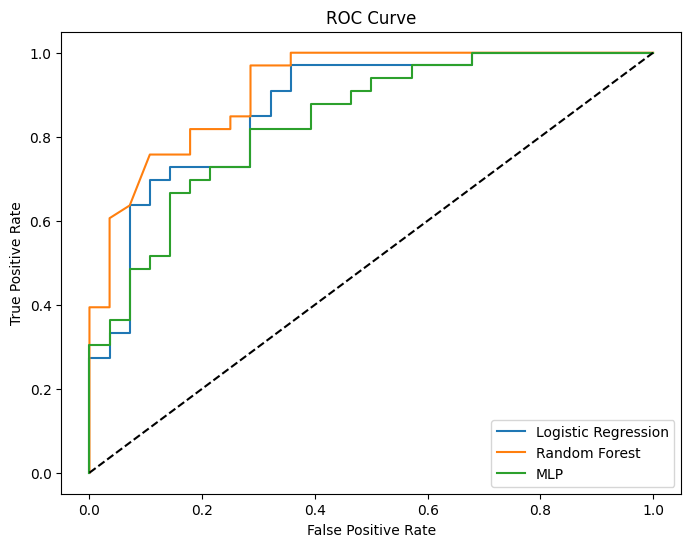

In [44]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(
    y_test,
    lr.predict_proba(X_test_scaled)[:,1]
)

plt.plot(
    fpr,
    tpr,
    label='Logistic Regression'
)

# Random Forest
fpr, tpr, _ = roc_curve(
    y_test,
    rf.predict_proba(X_test)[:,1]
)

plt.plot(
    fpr,
    tpr,
    label='Random Forest'
)

# MLP
fpr, tpr, _ = roc_curve(
    y_test,
    mlp.predict_proba(X_test_scaled)[:,1]
)

plt.plot(
    fpr,
    tpr,
    label='MLP'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


**### MODEL COMPARISON**

In [45]:
roc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
roc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
roc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
roc_mlp = roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1])

results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'MLP'
    ],

    'Accuracy':[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp)
    ],

    'Precision':[
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_mlp)
    ],

    'Recall':[
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_mlp)
    ],

    'F1 Score':[
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_mlp)
    ],

    'ROC-AUC':[
        roc_lr,
        roc_dt,
        roc_rf,
        roc_mlp
    ]
})

results = results.sort_values(
    by='Accuracy',
    ascending=False
)

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.836066   0.780488  0.969697  0.864865  0.916126
0  Logistic Regression  0.803279   0.769231  0.909091  0.833333  0.869048
3                  MLP  0.721311   0.710526  0.818182  0.760563  0.835498
1        Decision Tree  0.704918   0.702703  0.787879  0.742857  0.697511


**### MODEL TESTING**

In [46]:
# Patient data
patient = pd.DataFrame({
    'age':[55],
    'sex':[1],
    'cp':[2],
    'trestbps':[140],
    'chol':[250],
    'fbs':[0],
    'restecg':[1],
    'thalach':[150],
    'exang':[0],
    'oldpeak':[1.2],
    'slope':[2],
    'ca':[0],
    'thal':[2]
})

# Predict
prediction = best_rf.predict(patient)

# Probability
probability = best_rf.predict_proba(patient)

print("Prediction:", prediction[0])
print("Probability:", probability)

if prediction[0] == 1:
    print("Patient is likely to have Heart Disease")
else:
    print("Patient is unlikely to have Heart Disease")

Prediction: 1
Probability: [[0.13160755 0.86839245]]
Patient is likely to have Heart Disease


**### FEATURE IMPORTANCE**

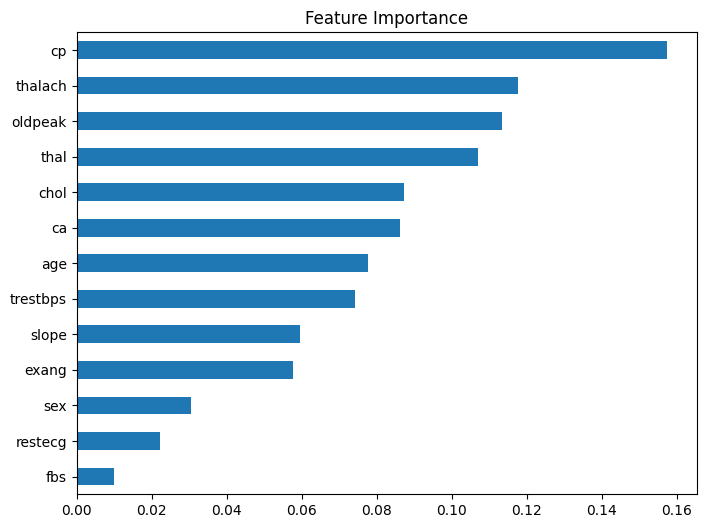

In [47]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()

**### CONCLUSION**

1. Multiple machine learning models were developed to predict heart disease.

2. Random Forest achieved the best overall performance due to its ensemble nature.

4. Feature importance analysis indicated that variables such as chest pain type, maximum heart rate achieved, ST depression, and number of major vessels significantly influenced prediction.

5. Machine learning can support healthcare professionals by enabling early screening and risk assessment for heart disease.